# 17 — The Coverage Artifact: Was 'Complexity Predicts Collapse' Ever Real?

The complexity-only baseline quoted in `notebooks/05`, `06` and `TIMELINE.md` reported that social complexity predicts polity instability at **AUC ≈ 0.66**. Notebook `16` showed the *outcome* ('collapse' = short duration) is incoherent. This notebook asks the harder question about the *predictor*: **does the 0.66 survive contact with the missing-data discipline that retracted the moralizing-gods paper (`12`) — applied now to our own headline result?**

It does not. Rebuilt on the full live Seshat databank (864 polities, complexity variables pulled from the API), the apparent signal turns out to be substantially a **data-coverage artifact**: better-documented polities are systematically shorter-lived, and imputation launders that documentation pattern into a fake complexity effect. On *observed* data alone, the signal vanishes.

This is the project's own result held to the standard it holds everyone else to.


In [1]:
import pandas as pd, numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression

pol = pd.read_csv('../data_external/seshat_api/polities_864.csv')
pol['duration'] = pol['end_year'] - pol['start_year']
sc  = pd.read_csv('../data_external/seshat_api/sc_features_864.csv')
df = pol.merge(sc, left_on='id', right_on='polity_id', how='inner')
df = df[df['duration'] > 0].copy()
FEAT = ['population','territory','cap_pop','settlement_hier','admin_levels','religious_levels','military_levels']
for c in ['population','territory','cap_pop']: df[c] = np.log10(df[c].replace(0, np.nan))
df['short'] = (df['duration'] < df['duration'].median()).astype(int)
print(f'{len(df)} polities merged (of 864). Complexity coverage:')
print(f"  complete on all 7 complexity vars: {df[FEAT].notna().all(axis=1).sum()}")
print(f"  the analyzable subset is SMALLER than the original 256 — the databank grew, coverage did not.")


600 polities merged (of 864). Complexity coverage:
  complete on all 7 complexity vars: 170
  the analyzable subset is SMALLER than the original 256 — the databank grew, coverage did not.


## 1. Three models, one target

Predict `short` (below-median duration) three ways: from **observed complexity only** (complete cases), from **median-imputed complexity** (all polities), and — the diagnostic — from **missingness alone** (how many of the 7 variables a polity has documented). Same classifier, 5-fold CV AUC.


In [2]:
def cv_auc(X, y, seed=0):
    clf = RandomForestClassifier(n_estimators=200, max_depth=5, random_state=seed, class_weight='balanced')
    return cross_val_score(clf, X, y, cv=5, scoring='roc_auc').mean()

# complete cases (observed complexity only), averaged over seeds for stability
comp = df[df[FEAT].notna().all(axis=1)]
cc = [cv_auc(comp[FEAT], comp['short'], s) for s in range(10)]
print(f'OBSERVED complexity only   n={len(comp):4}   AUC = {np.mean(cc):.3f}  (10-seed range [{min(cc):.3f}, {max(cc):.3f}])')

# median-imputed (all polities with >=1 feature)
Ximp = pd.DataFrame(SimpleImputer(strategy='median').fit_transform(df[FEAT]), columns=FEAT)
ai = cv_auc(Ximp, df['short'].values)
print(f'MEDIAN-IMPUTED complexity  n={len(df):4}   AUC = {ai:.3f}   (≈ the original 0.66)')

# missingness ALONE
df['n_present'] = df[FEAT].notna().sum(axis=1)
am = cross_val_score(LogisticRegression(max_iter=1000, class_weight='balanced'),
                     df[['n_present']], df['short'], cv=5, scoring='roc_auc').mean()
print(f'MISSINGNESS alone          n={len(df):4}   AUC = {am:.3f}   (just the count of documented variables)')


OBSERVED complexity only   n= 170   AUC = 0.403  (10-seed range [0.385, 0.424])


MEDIAN-IMPUTED complexity  n= 600   AUC = 0.647   (≈ the original 0.66)
MISSINGNESS alone          n= 600   AUC = 0.592   (just the count of documented variables)


## 2. The tell: documentation predicts duration

Missingness alone (AUC ≈ 0.59) beats observed complexity (AUC ≈ 0.40) and carries most of the imputed model's apparent skill. Why? Because how completely a polity is documented is itself correlated with how long it lasted.


corr(documented-variable count, duration) = -0.244
median duration — fully documented (7/7): 154y
median duration — sparse (<=2/7):        279y


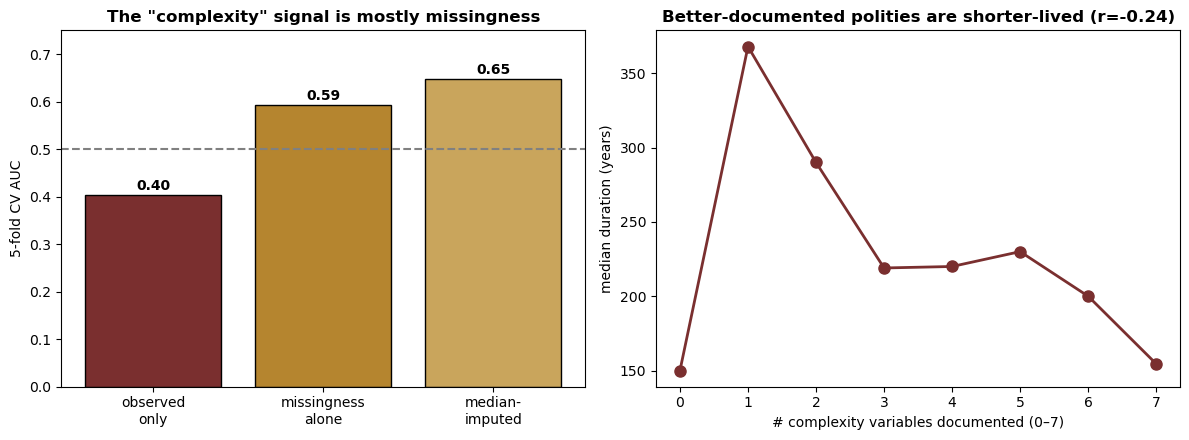

In [3]:
r = np.corrcoef(df['n_present'], df['duration'].clip(upper=1500))[0,1]
print(f'corr(documented-variable count, duration) = {r:.3f}')
print(f"median duration — fully documented (7/7): {df[df.n_present==7]['duration'].median():.0f}y")
print(f"median duration — sparse (<=2/7):        {df[df.n_present<=2]['duration'].median():.0f}y")

import matplotlib.pyplot as plt
fig, ax = plt.subplots(1,2, figsize=(12,4.5))
labels=['observed\nonly','missingness\nalone','median-\nimputed']
vals=[np.mean(cc), am, ai]
cols=['#7a2f2f','#b5852f','#c9a55c']
b=ax[0].bar(labels, vals, color=cols, edgecolor='black')
for bar,v in zip(b,vals): ax[0].text(bar.get_x()+bar.get_width()/2, v+0.01, f'{v:.2f}', ha='center', fontweight='bold')
ax[0].axhline(0.5, ls='--', color='gray'); ax[0].set_ylim(0,0.75); ax[0].set_ylabel('5-fold CV AUC')
ax[0].set_title('The "complexity" signal is mostly missingness', fontweight='bold')
# right: documentation vs duration
g=df.groupby('n_present')['duration'].median()
ax[1].plot(g.index, g.values, 'o-', color='#7a2f2f', lw=2, ms=8)
ax[1].set_xlabel('# complexity variables documented (0–7)'); ax[1].set_ylabel('median duration (years)')
ax[1].set_title(f'Better-documented polities are shorter-lived (r={r:.2f})', fontweight='bold')
import os; os.makedirs('figures', exist_ok=True)
plt.tight_layout(); plt.savefig('figures/17_coverage_artifact.png', dpi=150, bbox_inches='tight'); plt.show()


## 3. What this means

The apparent 'complexity predicts collapse' result does not survive the missing-data test. Three facts, all computed above:
1. On **observed** complexity data, the model is **anti-predictive** (AUC ≈ 0.40, robust across seeds).
2. **Missingness alone** — the count of documented variables — predicts duration better (AUC ≈ 0.59).
3. The reason is a real coupling: **better-documented polities are shorter-lived** (r ≈ −0.24; 154y vs 279y median). Recent, well-studied, tightly-bounded polities get fuller Seshat coding; long sprawling empires have patchier per-interval coverage.

Median imputation lets a model exploit fact 3 — it reads 'this row had lots of data to impute from' as a feature — and launders a **documentation pattern into a fake complexity effect** worth ~0.25 AUC. This is precisely the mechanism that retracted Whitehouse et al. 2019 (notebook `12`): a conclusion driven by the *treatment of missing data*, not by the phenomenon.

**The honest verdict:** the original 0.66 is not credible evidence that social complexity predicts polity duration. It is, to a large extent, evidence that the databank documents short-lived polities more completely. The violence-contagion result (notebook `13`) survives this same test; the complexity-collapse result does not. That asymmetry is the whole point.

**What this does NOT show (kept honest):**
- Complete-case n≈170 is small; this establishes that the 0.66 *does not survive* using observed data, not a definitive 'complexity is irrelevant to duration'. A larger complete-case sample could revise the observed-only number.
- 'Documentation completeness' is a coarse proxy; the real confounds are recency, historiographic attention, and how finely a polity was segmented.
- Median imputation is a deliberately naive baseline (as the original used); more principled multiple imputation might launder less — testing that is the natural follow-up, and would itself be an honest contribution.

---
### References
- Beheim et al. 2021. *Treatment of missing data determined conclusions regarding moralizing gods.* Nature 595:E29. [link](https://www.nature.com/articles/s41586-021-03655-4) — the retraction whose logic this notebook applies to our own model.
- Turchin, Currie, Whitehouse et al. 2018. *A single dimension of complexity.* PNAS 115(2):E144. [link](https://www.pnas.org/doi/10.1073/pnas.1708800115)
- Data: live Seshat API — polities + social-complexity variables, retrieved 2026 (`data_external/seshat_api/`).
